# Customer Segmentation using KMeans

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

## Load the dataset

In [74]:
df = pd.read_csv('Customers_data.csv')
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## Explore the dataset

### Check missing values

In [75]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Check null values

In [76]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Exploratory Data Analysis

#### Structure

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


#### Overview

In [78]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Normalise the data

We normalise the data to ensure that no column is superior or inferior.

In [79]:
scaler = StandardScaler()
features = scaler.fit_transform(df[['Annual Income (k$)', 'Spending Score (1-100)']]) # features array
features_df = pd.DataFrame(features, columns = ['Annual Income (k$)', 'Spending Score (1-100)'])  # features df
print(features_df)

     Annual Income (k$)  Spending Score (1-100)
0             -1.738999               -0.434801
1             -1.738999                1.195704
2             -1.700830               -1.715913
3             -1.700830                1.040418
4             -1.662660               -0.395980
..                  ...                     ...
195            2.268791                1.118061
196            2.497807               -0.861839
197            2.497807                0.923953
198            2.917671               -1.250054
199            2.917671                1.273347

[200 rows x 2 columns]


## Finding K

### 1. Evaluate inertia for different K

In [80]:
K = range(2,11)  # test K
inr = []  # list to store inertias
for i in K:
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(features)
    inr.append(kmeans.inertia_)
print(f'Inertias: {inr}')

Inertias: [273.6688866264201, 157.70400815035947, 109.22822707921347, 65.56840815571681, 60.13287487193422, 49.66824483736798, 37.319122878338824, 32.49508119910091, 30.059322694042212]


### 2. Visualise the curve of Inertia and K

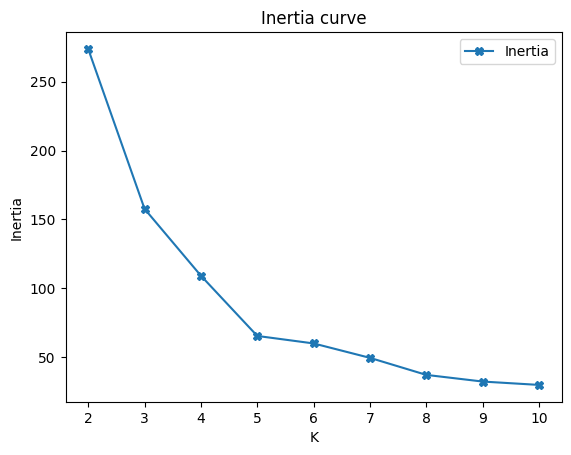

In [81]:
plt.plot(K, inr, marker = 'X')
plt.xticks(K)
plt.title('Inertia curve')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.legend(['Inertia'])
plt.show()

In the above graph, Inertia stops decreasing drastically at 5. Hence, From the above graph, we can conclude that K=5 would be the optimal choice.

### 3. Check with Silhouette score

In [85]:
k = range(2,11)
slh = []
for i in k:
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(features)
    score = silhouette_score(features, labels)
    slh.append(score)
max_score = slh.index(max(slh))
print(f'Silhouette scores: {slh}')
print(f'Highest score: {max_score}, number of K: {k[max_score]}')

Silhouette scores: [0.3973270007887498, 0.46658474419000145, 0.49434988482196796, 0.5546571631111091, 0.5138257534676561, 0.50200146805547, 0.4550112502601921, 0.4566624374485964, 0.44475993501732874]
Highest score: 3, number of K: 5


## Conclusion

From the elbow curve, the inertia showed a significant drop up to k=5 and flattened after that, suggesting k=5 as the optimal point. This was further confirmed by the silhouette score, which was highest at k=5, indicating well-separated and tight clusters. Hence, k=5 is chosen as the optimal number of clusters.

## Training

Train the model using K=5

In [83]:
kmeans = KMeans(n_clusters=5, random_state = 42)
labels = kmeans.fit_predict(features)
centroids = kmeans.cluster_centers_
print(f'Centroid: {centroids}')
print(f'Labels: {labels}')

Centroid: [[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]
Labels: [4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


## Visualise

Now, we will visualise our clusters and centroids using scatter plot. We will use scatter plot for this. Before that, here is a quick explanation of scatter plot:
A scatter plot is simply a graph where each data point is drawn as a dot at its (x, y) position. That's it. No lines, no bars. Just dots placed by their coordinates.

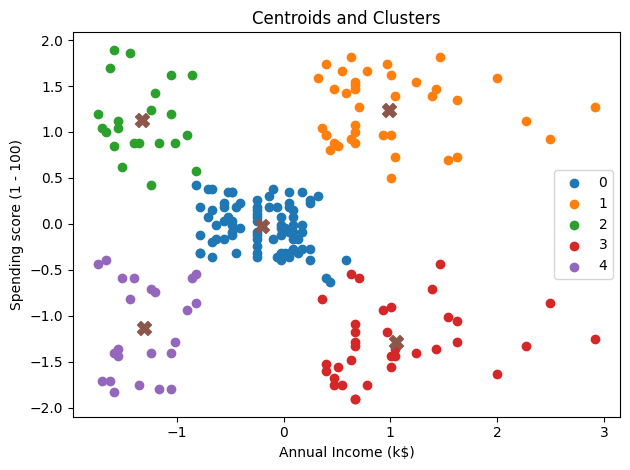

In [84]:
for i in range(5):
    f = features[labels == i]
    plt.scatter(f[:, 0], f[:, 1], label = i)
plt.scatter(centroids[:, 0], centroids[:, 1], marker = 'X', s = 100)
plt.title('Centroids and Clusters')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending score (1 - 100)')
plt.legend()
plt.tight_layout()
plt.show()

From the above visualisation, we can conclude that our training was successful!